# Week 1 fantasy range projections — guided walkthrough

This notebook is the short path through the project. It builds a **preseason** player prior from completed seasons only, then simulates the football stat process instead of predicting fantasy points directly.

**Flow:** historical player games → team opportunity → player share/efficiency priors → simulated targets/carries/yards/TDs → fantasy-point distribution → calibration check.

Run the cells in order. The first run downloads the public nflverse weekly player files if `data/raw/player_games.csv` is absent.

## 1. Imports and load the historical player-game table

`normalize_player_games` is the explicit data boundary. It keeps a single row per player-game, derives team targets/rushes/pass attempts **before** excluding QBs, and then retains only RB/WR/TE outputs. The resulting fields such as `team_targets` are realized historical labels; they are never used as same-game features at prediction time.

In [1]:
from pathlib import Path
import sys

# Support running directly from a clone before an editable install.
ROOT = Path.cwd().resolve()
if not (ROOT / 'src').exists():
    ROOT = ROOT.parent
if str(ROOT / 'src') not in sys.path:
    sys.path.insert(0, str(ROOT / 'src'))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from fantasy_ranges.data import fetch_player_stats, normalize_player_games
from fantasy_ranges.features import build_preseason_features
from fantasy_ranges.baselines import PositionNormalBaseline, UsageNearestNeighbors, expected_points
from fantasy_ranges.simulation import ComponentSimulator
from fantasy_ranges.backtest import run_week1_backtest

DATA_PATH = ROOT / 'data/raw/player_games.csv'
if not DATA_PATH.exists():
    # Requires internet only on the first run. CSV ingestion does not require pyarrow.
    games = fetch_player_stats(range(2021, 2026), DATA_PATH.parent)
else:
    games = normalize_player_games(pd.read_csv(DATA_PATH, low_memory=False))

games.shape, games[['season', 'week', 'position']].head()

((26097, 160),
    season  week position
 0    2021     1       TE
 1    2021     1       WR
 2    2021     1       WR
 3    2021     1       TE
 4    2021     1       TE)

In [2]:
games

,player_id,player_name,player_name.1,position,position_group,headshot_url,season,week,season_type,game_id,...,routes,route_participation,snap_share,team_targets,team_rush_attempts,team_pass_attempts,target_share_game,rush_share_game,touchdowns,game_key
0,00-0024243,M.Lewis,Marcedes Lewis,TE,TE,https://static.www.nfl.com/image/private/f_aut...,2021,1,REG,2021_01_GB_NO,...,0.0,0.0,0.0,33,15,51.5625,0.030303,0.000000,0,2021_01_GB_NO
1,00-0026035,D.Amendola,Danny Amendola,WR,WR,https://static.www.nfl.com/image/private/f_aut...,2021,1,REG,2021_01_JAX_HOU,...,0.0,0.0,0.0,32,37,50.0000,0.156250,0.000000,1,2021_01_JAX_HOU
2,00-0026189,D.Jackson,DeSean Jackson,WR,WR,https://static.www.nfl.com/image/private/f_aut...,2021,1,REG,2021_01_CHI_LA,...,0.0,0.0,0.0,26,18,40.6250,0.076923,0.000000,0,2021_01_CHI_LA
3,00-0027061,J.Cook,Jared Cook,TE,TE,https://static.www.nfl.com/image/private/f_aut...,2021,1,REG,2021_01_LAC_WAS,...,0.0,0.0,0.0,46,24,71.8750,0.173913,0.000000,0,2021_01_LAC_WAS
4,00-0027656,R.Gronkowski,Rob Gronkowski,TE,TE,https://static.www.nfl.com/image/private/f_aut...,2021,1,REG,2021_01_DAL_TB,...,0.0,0.0,0.0,45,14,70.3125,0.177778,0.000000,2,2021_01_DAL_TB
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
26092,00-0040729,J.Bech,Jack Bech,WR,WR,https://static.www.nfl.com/image/upload/f_auto...,2025,18,REG,2025_18_KC_LV,...,0.0,0.0,0.0,26,29,40.6250,0.076923,0.000000,0,2025_18_KC_LV
26093,00-0040730,R.Harvey,RJ Harvey,RB,RB,https://static.www.nfl.com/image/upload/f_auto...,2025,18,REG,2025_18_LAC_DEN,...,0.0,0.0,0.0,23,23,35.9375,0.173913,0.652174,0,2025_18_LAC_DEN
26094,00-0040734,T.Henderson,TreVeyon Henderson,RB,RB,https://static.www.nfl.com/image/upload/f_auto...,2025,18,REG,2025_18_MIA_NE,...,0.0,0.0,0.0,20,26,31.2500,0.000000,0.500000,2,2025_18_MIA_NE
26095,00-0040735,L.Burden,Luther Burden III,WR,WR,https://static.www.nfl.com/image/upload/f_auto...,2025,18,REG,2025_18_DET_CHI,...,0.0,0.0,0.0,29,17,45.3125,0.137931,0.058824,0,2025_18_DET_CHI


## 2. The core aggregation

For every historical team-game, we aggregate all player rows to get the pool of opportunities. A receiver's game-level target share is `targets / team_targets`; a rusher's rush share is `carries / team_rush_attempts`. The model treats these shares as uncertain latent quantities in the future.

In [3]:
team_game = (games.groupby(['season', 'week', 'team'], as_index=False)
    .agg(team_targets=('targets', 'sum'),
         team_carries=('carries', 'sum'),
         team_pass_attempts=('team_pass_attempts', 'first'),
         rb_wr_te_points=('fantasy_points_ppr', 'sum')))
team_game.head()

# The same calculations already live in `normalize_player_games`; this makes them visible.
games[['player_name', 'position', 'targets', 'team_targets', 'target_share_game',
       'carries', 'team_rush_attempts', 'rush_share_game']].head(10)

,player_name,position,targets,team_targets,target_share_game,carries,team_rush_attempts,rush_share_game
0,M.Lewis,TE,1,33,0.030303,0,15,0.000000
1,D.Amendola,WR,5,32,0.156250,0,37,0.000000
2,D.Jackson,WR,2,26,0.076923,0,18,0.000000
3,J.Cook,TE,8,46,0.173913,0,24,0.000000
4,R.Gronkowski,TE,8,45,0.177778,0,14,0.000000
5,E.Sanders,WR,8,48,0.166667,0,16,0.000000
6,A.Roberts,WR,0,32,0.000000,0,37,0.000000
7,J.Graham,TE,2,40,0.050000,0,23,0.000000
8,A.Brown,WR,7,45,0.155556,1,14,0.071429
9,A.Green,WR,6,32,0.187500,0,28,0.000000


## 3. Build a Week 1 prior without leakage

Pretend we are about to project the 2025 opener. The candidate list supplies identity/team/position only. `build_preseason_features` filters all history to `season < 2025`, applies recency weighting, and shrinks players with little evidence toward a positional average.

In production, replace `candidates` with a curated 2026 roles file containing roster, rookie/team-change, injury, and expected team-volume inputs. Historical Week 1 rows are used here only because they give us a labeled backtest universe.

In [4]:
TARGET_SEASON = 2025
week1_candidates = games.loc[(games.season == TARGET_SEASON) & (games.week == 1),
    ['player_id', 'player_name', 'position', 'team']].drop_duplicates()
priors = build_preseason_features(games, week1_candidates, TARGET_SEASON)

prior_columns = ['player_name', 'position', 'team', 'games_sample', 'prior_target_share',
                 'prior_rush_share', 'prior_catch_rate', 'expected_team_pass_attempts',
                 'role_uncertainty', 'rookie', 'team_change']
priors.sort_values('prior_target_share', ascending=False)[prior_columns].head(12)

,player_name,position,team,games_sample,prior_target_share,prior_rush_share,prior_catch_rate,expected_team_pass_attempts,role_uncertainty,rookie,team_change
231,M.Nabers,WR,NYG,15,0.357041,0.015280,0.645966,47.024609,0.301254,0,0
6,D.Adams,WR,LA,64,0.314660,0.002300,0.606071,47.954512,0.345313,0,1
79,A.Brown,WR,PHI,60,0.308349,0.000700,0.658761,38.786139,0.129841,0,0
225,P.Nacua,WR,LA,28,0.304638,0.029081,0.684375,47.954512,0.168436,0,0
96,J.Jefferson,WR,MIN,61,0.296745,0.006822,0.669396,44.208861,0.120939,0,0
53,D.Moore,WR,CHI,68,0.283836,0.027289,0.646089,41.859694,0.117555,0,0
99,C.Lamb,WR,DAL,65,0.276478,0.034074,0.700081,56.986861,0.125834,0,0
8,S.Diggs,WR,NE,58,0.276257,0.004709,0.693786,42.486242,0.339723,0,1
16,T.Hill,WR,MIA,67,0.276045,0.020842,0.677400,51.300578,0.131652,0,0
39,C.Kupp,WR,SEA,50,0.275010,0.012444,0.678581,50.090158,0.346067,0,1


### What role uncertainty means

It is not an arbitrary fantasy-points standard deviation. It increases when a player has a small sample, is a rookie, changed teams, or had unstable share. In the simulator it **lowers the concentration** of the target-share/carry-share beta distribution. That means uncertainty enters before opportunities and naturally propagates into yardage and touchdowns.

In [5]:
# Inspect a stable-looking prior and a higher-uncertainty prior from this historical candidate set.
priors.sort_values(['role_uncertainty', 'prior_target_share'], ascending=[True, False])[prior_columns].head(5), \
priors.sort_values('role_uncertainty', ascending=False)[prior_columns].head(5)

(     player_name position team  games_sample  prior_target_share  \
 114    K.Nwangwu       RB  NYJ            33            0.004769   
 76   G.Olszewski       WR  NYG            43            0.007849   
 110    T.Wallace       WR  BAL            33            0.028954   
 73      D.Sample       TE  CIN            37            0.052460   
 196      D.Davis       WR  LAC            32            0.034270   
 
      prior_rush_share  prior_catch_rate  expected_team_pass_attempts  \
 114          0.031029          0.090270                    50.770706   
 76           0.007421          0.138829                    47.024609   
 110          0.000000          0.410186                    41.718750   
 73           0.001682          0.805295                    57.941060   
 196          0.038243          0.566079                    44.672440   
 
      role_uncertainty  rookie  team_change  
 114          0.088583       0            0  
 76           0.089002       0            0  
 110  

## 4. A transparent point-center baseline

Before simulating, compute the center implied by prior opportunities and efficiency:

`expected targets = expected team pass attempts × 0.64 × prior target share`

The baseline then adds receptions, yards, and strongly-shrunk touchdown rates. It is useful as a sanity check, not the final answer.

In [6]:
priors = priors.copy()
priors['baseline_center'] = expected_points(priors)
priors[['player_name', 'position', 'baseline_center', 'role_uncertainty']].sort_values(
    'baseline_center', ascending=False).head(15)

,player_name,position,baseline_center,role_uncertainty
122,J.Chase,WR,20.625390,0.115620
21,C.McCaffrey,RB,20.030823,0.122971
99,C.Lamb,WR,19.790398,0.125834
226,J.Gibbs,RB,19.112702,0.110392
56,S.Barkley,RB,18.883950,0.115748
82,J.Jacobs,RB,18.199140,0.114223
231,M.Nabers,WR,17.716478,0.301254
264,B.Thomas,WR,17.376670,0.277285
15,D.Henry,RB,17.266285,0.108024
16,T.Hill,WR,17.157722,0.131652


## 5. Component Monte Carlo simulation

For each draw, the model samples:

1. team pass/rush volume (gamma-Poisson / negative-binomial-like);
2. target/carry share (beta-binomial);
3. catches conditional on targets;
4. positive, right-skewed yardage conditional on catches/carries; and
5. receiving/rushing TDs with strongly pooled rates.

The `fit` call estimates positional priors from the completed history only. Choose one player dynamically so this notebook remains usable even if names/teams change.

In [7]:
model = ComponentSimulator(simulations=20_000, seed=42).fit(games.loc[games.season < TARGET_SEASON])
player = priors.sort_values('baseline_center', ascending=False).iloc[0]
distribution = model.simulate(player)
summary = distribution.summary()
pd.Series({'player': player.player_name, 'position': player.position} | summary)

player                J.Chase
position                   WR
p10                  8.097896
p25                  12.82213
p50                 19.736982
p75                 28.213673
p90                 37.170181
mean                 21.50995
role_uncertainty      0.11562
p_10_plus             0.84395
p_15_plus             0.67095
p_20_plus             0.49115
dtype: object

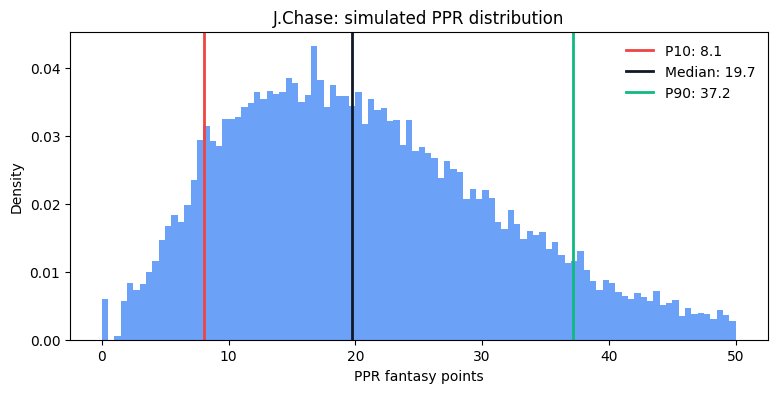

In [8]:
fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(distribution.samples, bins=np.arange(0, 50.5, .5), density=True, color='#3b82f6', alpha=.75)
for label, q, color in [('P10', .1, '#ef4444'), ('Median', .5, '#111827'), ('P90', .9, '#10b981')]:
    value = np.quantile(distribution.samples, q)
    ax.axvline(value, color=color, lw=2, label=f'{label}: {value:.1f}')
ax.set(title=f"{player.player_name}: simulated PPR distribution", xlabel='PPR fantasy points', ylabel='Density')
ax.legend(frameon=False)
plt.show()

## 6. Same median, different range

To isolate role uncertainty, we anchor two WRs to the same 16-point center. The first row retains an established player's history; the second is a rookie and therefore uses a positional prior with low beta concentration. This is the product behavior the project is designed to surface.

In [9]:
veteran = priors.loc[priors.position.eq('WR')].sort_values('games_sample', ascending=False).iloc[0].copy()
rookie = veteran.copy()
rookie['player_id'], rookie['player_name'], rookie['games_sample'] = 'walkthrough_rookie', 'Illustrative Rookie WR', 0
rookie['rookie'], rookie['team_change'], rookie['role_uncertainty'] = 1, 1, .92
for row in (veteran, rookie):
    row['expected_fantasy_points'] = 16.0  # same center; shape still comes from component model
veteran['role_uncertainty'] = min(veteran['role_uncertainty'], .15)
draws = {'Established WR': model.simulate(veteran, seed_offset=1).samples,
         'Rookie WR': model.simulate(rookie, seed_offset=2).samples}
pd.DataFrame([{ 'profile': name, 'P10': np.quantile(values, .1), 'Median': np.median(values),
                'P90': np.quantile(values, .9), '80% width': np.quantile(values, .9)-np.quantile(values, .1)}
              for name, values in draws.items()])

,profile,P10,Median,P90,80% width
0,Established WR,5.320808,16.0,33.292502,27.971693
1,Rookie WR,0.000000,16.0,59.896868,59.896868


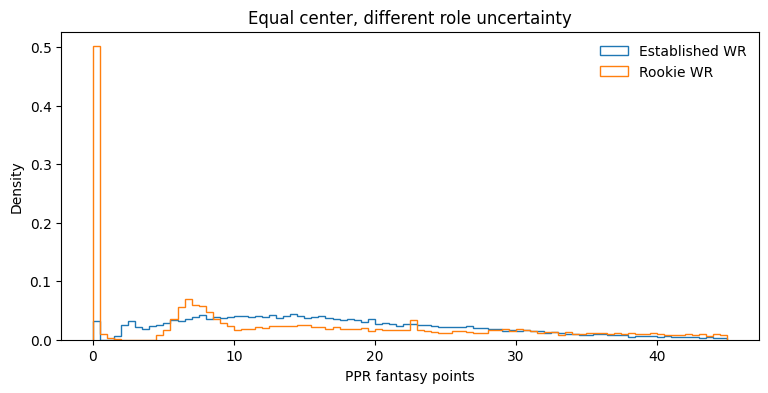

In [10]:
fig, ax = plt.subplots(figsize=(9, 4))
for name, values in draws.items():
    ax.hist(values, bins=np.arange(0, 45.5, .5), density=True, histtype='step', lw=2, label=name)
ax.set(title='Equal center, different role uncertainty', xlabel='PPR fantasy points', ylabel='Density')
ax.legend(frameon=False)
plt.show()

## 7. Validate ranges, not just point estimates

This walk-forward backtest holds out each Week 1 from 2022–25. For each season, all player priors use only prior seasons. It compares the raw component model with a position-normal and empirical-neighbor baseline. The conformal version calibrates component quantiles using **previous** Week 1 forecast errors, never the current holdout.

Use 2,000 draws here for notebook speed; the command-line run can use more.

In [11]:
predictions, metrics = run_week1_backtest(games, seasons=range(2022, 2026), simulations=2_000)
metrics[['model', 'n', 'median_ae', 'coverage_50', 'width_50', 'coverage_80', 'width_80']]

,model,n,median_ae,coverage_50,width_50,coverage_80,width_80
0,component_mc,1225,4.434488,0.413061,6.852545,0.749388,13.355593
1,component_mc_conformal,921,4.155313,0.507058,7.897805,0.825190,14.443958
2,position_normal,921,4.306199,0.554832,7.483578,0.842562,12.951820
3,usage_knn,921,4.238599,0.628664,8.212975,0.890337,14.890163


## 8. Reading the result and next steps

- Prefer the **component MC + walk-forward conformal** model when its coverage is closest to 50% and 80% without an unreasonable width penalty.
- Do not call the raw simulator calibrated if its coverage misses nominal coverage; the backtest is meant to catch exactly that.
- For 2026, create a versioned candidate/roles input instead of using historical Week 1 players. Include team, rookie/team-change flags, expected team volume, and optional consensus center.
- Routes, snaps, red-zone usage, injury status, QB/coaching changes, and external consensus are valuable feature additions, but they must be lagged/as-of dated and should widen priors when uncertain.

The reusable implementation lives in `src/fantasy_ranges/`; this notebook deliberately exposes the minimal conceptual path rather than duplicating the package.

## 9. Actual 2026 Week 1 projections

The earlier rookie comparison was only a teaching aid. This final section loads the real 2026 active RB/WR/TE roster output. If it is not present yet, it builds it from the roster snapshot, the completed 2021–25 player-game data, 20,000 simulations per player, and the walk-forward conformal calibration.

In [12]:
from fantasy_ranges.data import fetch_roster, week1_candidates_from_roster
from fantasy_ranges.projections import project_week1

PROJECTION_PATH = ROOT / 'outputs/week1_2026/projections.csv'
if PROJECTION_PATH.exists():
    week1_2026 = pd.read_csv(PROJECTION_PATH)
else:
    roster_2026 = fetch_roster(2026, ROOT / 'data/inputs')
    candidates_2026 = week1_candidates_from_roster(roster_2026, 2026)
    week1_2026 = project_week1(games, candidates_2026, 2026, simulations=20_000)
    PROJECTION_PATH.parent.mkdir(parents=True, exist_ok=True)
    week1_2026.to_csv(PROJECTION_PATH, index=False)

week1_2026[['player_name', 'position', 'team', 'p10', 'p25', 'p50', 'p75', 'p90',
           'p_10_plus', 'p_20_plus', 'uncertainty', 'calibration']].sort_values(
               ['position', 'p50'], ascending=[True, False]).groupby('position').head(10)

,player_name,position,team,p10,p25,p50,p75,p90,p_10_plus,p_20_plus,uncertainty,calibration
0,Christian McCaffrey,RB,SF,8.741739,12.970558,18.985171,27.404242,35.212508,0.90260,0.48580,low,walk_forward_conformal
1,Bijan Robinson,RB,ATL,6.248369,9.698009,14.853092,22.125920,28.808717,0.79615,0.28620,low,walk_forward_conformal
2,Jahmyr Gibbs,RB,DET,5.189036,8.730680,14.025817,21.810579,28.779295,0.74590,0.27060,low,walk_forward_conformal
3,Jonathan Taylor,RB,IND,5.292220,8.682299,13.983713,21.552541,28.650726,0.74390,0.26260,low,walk_forward_conformal
4,Saquon Barkley,RB,PHI,5.100166,8.112881,12.791989,19.755062,26.044079,0.71210,0.20130,low,walk_forward_conformal
5,De'Von Achane,RB,MIA,4.810314,7.780568,12.559329,19.520690,25.745119,0.68930,0.19400,low,walk_forward_conformal
6,Derrick Henry,RB,BAL,4.345996,7.444687,12.388035,19.752182,26.350310,0.67345,0.20450,low,walk_forward_conformal
7,Kyren Williams,RB,LA,4.150054,6.982709,11.700980,18.731508,24.850139,0.64030,0.16655,low,walk_forward_conformal
8,D'Andre Swift,RB,CHI,4.262493,7.031421,11.524739,18.371585,24.400675,0.63855,0.15615,low,walk_forward_conformal
9,James Cook,RB,BUF,3.886085,6.697723,11.484262,18.524305,24.831708,0.62935,0.16290,low,walk_forward_conformal
